Assignment 9  
Nandan M  
25mda083

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot Two Time Series Together
Given two series: temperature and humidity over 6 months,
- Plot them on the same figure with different y-axes
- Add a legend and axis labels

### Data Preparation and cleaning

In [2]:
raw_input_df = pd.read_csv("./dataset/DataSet_Question_1.csv")

In [3]:
# check item counts, data types, and non-null values
raw_input_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1068 non-null   object 
 1   date_id     1068 non-null   float64
 2   wind        1068 non-null   float64
 3   desc        1068 non-null   object 
 4   temp        1038 non-null   float64
 5   baro        1068 non-null   float64
 6   hum         1068 non-null   int64  
 7   day         1068 non-null   object 
 8   month       1068 non-null   int64  
 9   day_date    1068 non-null   int64  
 10  year        1068 non-null   int64  
 11  day_name    1068 non-null   int64  
 12  Start_hour  1068 non-null   object 
 13  End_hour    1068 non-null   object 
dtypes: float64(4), int64(5), object(5)
memory usage: 116.9+ KB


Since temperature column has some missing values, we will first check the missing values and see what other columns has value in those rows

In [4]:
raw_input_df[raw_input_df['temp'].isnull()]

,date,date_id,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,Start_hour,End_hour
491,"Wednesday 9 September 2009, 18.00 — 00.00",1.252519e+12,0.0,No weather data available,NaN,0.0,0,2009-09-09,9,9,2009,2,18:00,00:00
552,"Friday 25 September 2009, 00.00 — 06.00",1.253837e+12,0.0,No weather data available,NaN,0.0,0,2009-09-25,9,25,2009,4,00:00,06:00
583,"Friday 2 October 2009, 18.00 — 00.00",1.254506e+12,0.0,No weather data available,NaN,0.0,0,2009-10-02,10,2,2009,4,18:00,00:00
584,"Saturday 3 October 2009, 00.00 — 06.00",1.254528e+12,0.0,No weather data available,NaN,0.0,0,2009-10-03,10,3,2009,5,00:00,06:00
585,"Saturday 3 October 2009, 06.00 — 12.00",1.254550e+12,0.0,No weather data available,NaN,0.0,0,2009-10-03,10,3,2009,5,06:00,12:00
586,"Saturday 3 October 2009, 12.00 — 18.00",1.254571e+12,0.0,No weather data available,NaN,0.0,0,2009-10-03,10,3,2009,5,12:00,18:00
587,"Saturday 3 October 2009, 18.00 — 00.00",1.254593e+12,0.0,No weather data available,NaN,0.0,0,2009-10-03,10,3,2009,5,18:00,00:00
588,"Sunday 4 October 2009, 00.00 — 06.00",1.254614e+12,0.0,No weather data available,NaN,0.0,0,2009-10-04,10,4,2009,6,00:00,06:00
589,"Sunday 4 October 2009, 06.00 — 12.00",1.254636e+12,0.0,No weather data available,NaN,0.0,0,2009-10-04,10,4,2009,6,06:00,12:00
590,"Sunday 4 October 2009, 12.00 — 18.00",1.254658e+12,0.0,No weather data available,NaN,0.0,0,2009-10-04,10,4,2009,6,12:00,18:00


In [5]:
cleaned_df = raw_input_df[raw_input_df['temp'].notnull()].reset_index(drop=True)
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1038 non-null   object 
 1   date_id     1038 non-null   float64
 2   wind        1038 non-null   float64
 3   desc        1038 non-null   object 
 4   temp        1038 non-null   float64
 5   baro        1038 non-null   float64
 6   hum         1038 non-null   int64  
 7   day         1038 non-null   object 
 8   month       1038 non-null   int64  
 9   day_date    1038 non-null   int64  
 10  year        1038 non-null   int64  
 11  day_name    1038 non-null   int64  
 12  Start_hour  1038 non-null   object 
 13  End_hour    1038 non-null   object 
dtypes: float64(4), int64(5), object(5)
memory usage: 113.7+ KB


In [6]:
cleaned_df.describe()

,date_id,wind,temp,baro,hum,month,day_date,year,day_name
count,1.038000e+03,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000,1038.000000
mean,1.476421e+12,11.892100,30.314066,1006.868979,74.845857,7.771676,19.279383,2016.171484,2.947013
std,2.311002e+11,6.759679,3.542770,12.729520,12.053694,3.100516,7.284081,7.383912,2.035861
min,1.252454e+12,0.000000,21.000000,672.000000,37.000000,1.000000,1.000000,2009.000000,0.000000
25%,1.258702e+12,6.000000,28.000000,1003.000000,66.000000,7.000000,15.000000,2009.000000,1.000000
50%,1.264302e+12,14.000000,30.000000,1006.000000,75.000000,7.000000,20.000000,2010.000000,3.000000
75%,1.721585e+12,18.000000,34.000000,1012.000000,84.000000,10.000000,25.000000,2024.000000,5.000000
max,1.722276e+12,22.000000,38.000000,1019.000000,100.000000,12.000000,31.000000,2024.000000,6.000000


In [7]:
cleaned_df

,date,date_id,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,Start_hour,End_hour
0,"Sunday 14 July 2024, 18.00 — 00.00",1.720980e+12,9.0,Drizzle. Fog.,30.0,1003.0,82,2024-07-14,7,14,2024,6,18:00,00:00
1,"Monday 15 July 2024, 00.00 — 06.00",1.721002e+12,14.0,Fog.,29.0,1002.0,80,2024-07-15,7,15,2024,0,00:00,06:00
2,"Monday 15 July 2024, 06.00 — 12.00",1.721023e+12,17.0,Drizzle. Broken clouds.,29.0,1003.0,82,2024-07-15,7,15,2024,0,06:00,12:00
3,"Monday 15 July 2024, 12.00 — 18.00",1.721045e+12,13.0,Drizzle. Broken clouds.,29.0,1001.0,85,2024-07-15,7,15,2024,0,12:00,18:00
4,"Monday 15 July 2024, 18.00 — 00.00",1.721066e+12,19.0,Fog.,29.0,1002.0,84,2024-07-15,7,15,2024,0,18:00,00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1033,"Saturday 30 January 2010, 18.00 — 00.00",1.264874e+12,10.0,Passing clouds.,26.0,1016.0,76,2010-01-30,1,30,2010,5,18:00,00:00
1034,"Sunday 31 January 2010, 00.00 — 06.00",1.264896e+12,0.0,Clear.,23.0,1015.0,91,2010-01-31,1,31,2010,6,00:00,06:00
1035,"Sunday 31 January 2010, 06.00 — 12.00",1.264918e+12,7.0,Haze.,29.0,1017.0,75,2010-01-31,1,31,2010,6,06:00,12:00
1036,"Sunday 31 January 2010, 12.00 — 18.00",1.264939e+12,16.0,Passing clouds.,29.0,1014.0,55,2010-01-31,1,31,2010,6,12:00,18:00


Now check for duplicate rows

In [8]:
# now check for duplicate rows all columns
cleaned_df.duplicated().sum()

np.int64(427)

In [9]:
validated_df = cleaned_df.drop_duplicates().reset_index(drop=True)
validated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 611 entries, 0 to 610
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        611 non-null    object 
 1   date_id     611 non-null    float64
 2   wind        611 non-null    float64
 3   desc        611 non-null    object 
 4   temp        611 non-null    float64
 5   baro        611 non-null    float64
 6   hum         611 non-null    int64  
 7   day         611 non-null    object 
 8   month       611 non-null    int64  
 9   day_date    611 non-null    int64  
 10  year        611 non-null    int64  
 11  day_name    611 non-null    int64  
 12  Start_hour  611 non-null    object 
 13  End_hour    611 non-null    object 
dtypes: float64(4), int64(5), object(5)
memory usage: 67.0+ KB


In [10]:
validated_df.describe()

,date_id,wind,temp,baro,hum,month,day_date,year,day_name
count,6.110000e+02,611.000000,611.000000,611.000000,611.000000,611.000000,611.000000,611.000000,611.000000
mean,1.305056e+12,8.013093,28.963993,1009.710311,77.980360,8.310966,17.469722,2010.700491,3.013093
std,1.388876e+11,6.000259,3.628487,15.940346,13.262159,3.954022,8.285499,4.450491,1.990920
min,1.252454e+12,0.000000,21.000000,672.000000,37.000000,1.000000,1.000000,2009.000000,0.000000
25%,1.256072e+12,3.000000,26.000000,1008.000000,68.000000,7.000000,11.000000,2009.000000,1.000000
50%,1.259690e+12,7.000000,28.000000,1012.000000,80.000000,10.000000,18.000000,2009.000000,3.000000
75%,1.262984e+12,12.000000,31.000000,1014.000000,89.000000,11.000000,24.000000,2010.000000,5.000000
max,1.722276e+12,22.000000,38.000000,1019.000000,100.000000,12.000000,31.000000,2024.000000,6.000000


In [11]:
# check year, month, day ranges
print("Year:", validated_df['year'].unique())
print("Month:", validated_df['month'].unique())
print("Day Name:", validated_df['day_name'].unique())

Year: [2024 2009 2010]
Month: [ 7  9 10 11 12  1]
Day Name: [6 0 1 2 3 4 5]


In [12]:
# check months in each year
print("2009:", validated_df[validated_df['year'] == 2009]['month'].unique())
print("2010:", validated_df[validated_df['year'] == 2010]['month'].unique())
print("2024:", validated_df[validated_df['year'] == 2024]['month'].unique())

2009: [ 9 10 11 12]
2010: [1]
2024: [7]


In [13]:
# since there are multuple records per day, we need to aggregate to daily level to be consistent
# ensure day_date is datetime
fin_df = validated_df.copy()
# convert day to datetime
fin_df["day"] = pd.to_datetime(fin_df["day"])

# aggregate to daily mean so that each day has a single record
daily_df = (
    fin_df.groupby("day", as_index=False)
      .mean(numeric_only=True)
      .sort_values("day")
)

In [14]:
# labels on day, month_year columns
daily_df["day_label"] = daily_df["day"].dt.strftime("%d")
daily_df["month_year"] = daily_df["day"].dt.strftime("%b %Y")

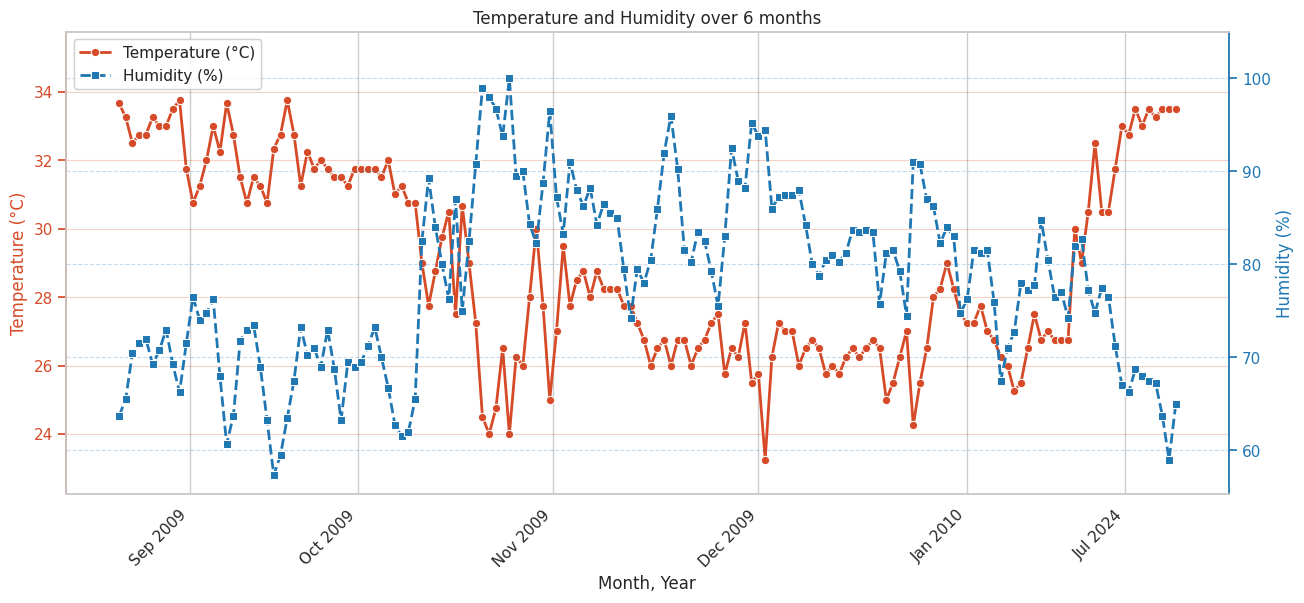

In [15]:
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(15, 6))

temp_color = "#d64a27"   
hum_color  = "#1f77b4" 

# Temperature at left axis
l1 = sns.lineplot(
    data=daily_df,
    x=range(len(daily_df)),
    y="temp",
    ax=ax1,
    marker="o",
    linewidth=2,
    color=temp_color,
    label="Temperature (°C)"    
)
ax1.set_ylabel("Temperature (°C)", color=temp_color)
ax1.tick_params(axis="y", colors=temp_color)
ax1.spines["left"].set_color(temp_color)

# Humidity at right axis
ax2 = ax1.twinx()
l2 = sns.lineplot(
    data=daily_df,
    x=range(len(daily_df)),
    y="hum",
    ax=ax2,
    marker="s",
    linestyle="--",
    linewidth=2,
    color=hum_color,
    label="Humidity (%)",
    
)
ax2.set_ylabel("Humidity (%)", color=hum_color)
ax2.label_outer()
ax2.tick_params(axis="y", colors=hum_color)
ax2.spines["right"].set_color(hum_color)

# month centers for x-ticks
month_centers = (
    daily_df
    .reset_index()
    .groupby("month_year")["index"]
    .mean()
)

ax1.set_xticks(month_centers.values)
ax1.set_xticklabels(month_centers.index, rotation=45, ha="right")

ax1.set_xlabel("Month, Year")

# combining lines for legend
lines = l1.lines + l2.lines
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")
ax2.legend(lines, labels, loc="upper left")

ax1.grid(False)
ax2.grid(False)

# drid for temp at left
ax1.yaxis.grid(
    True,
    color=temp_color,
    alpha=0.25,
    linestyle="-",
    linewidth=0.8
)
t_min, t_max = daily_df["temp"].min(), daily_df["temp"].max()
ax1.set_ylim(t_min - 1, t_max + 2)


# grid for humidity at right
ax2.yaxis.grid(
    True,
    color=hum_color,
    alpha=0.25,
    linestyle="--",
    linewidth=0.8
)
ax1.xaxis.grid(True)
h_min, h_max = daily_df["hum"].min(), daily_df["hum"].max()
ax2.set_ylim(h_min - 2, h_max + 5)

plt.title("Temperature and Humidity over 6 months")
plt.show()

---

# 2. Fit a Simple Linear Regression
Write Python code to:  
- Load a dataset containing hours_studied and exam_score  
- Fit a simple linear regression model  
- Print slope & intercept  
- Plot data points and the regression line  


In [16]:
from sklearn.linear_model import LinearRegression

# load dataset
raw_df = pd.read_csv("dataset/Student_Scores.csv")

In [17]:
# check dataset
raw_df

,Student_ID,Hours,Scores
0,1,2.5,21
1,2,5.1,47
2,3,3.2,27
3,4,8.5,75
4,5,3.5,30
5,6,1.5,20
6,7,9.2,88
7,8,5.5,60
8,9,8.3,81
9,10,2.7,25


In [18]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_ID  11 non-null     int64  
 1   Hours       11 non-null     float64
 2   Scores      11 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 396.0 bytes


In [19]:
raw_df.describe()

,Student_ID,Hours,Scores
count,11.000000,11.000000,11.000000
mean,6.000000,5.245455,50.818182
std,3.316625,2.773937,27.661591
min,1.000000,1.500000,20.000000
25%,3.500000,2.950000,26.000000
50%,6.000000,5.100000,47.000000
75%,8.500000,8.000000,78.000000
max,11.000000,9.200000,88.000000


In [20]:
# prepare feature and label
X = raw_df[["Hours"]]
y = raw_df["Scores"]

In [21]:
# fit linear regression model
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
# print slope and intercept
slope_skl_model = model.coef_[0]
intercept_skl_model = model.intercept_

print(f"Slope (m): {slope_skl_model}")
print(f"Intercept (c): {intercept_skl_model}")

Slope (m): 9.783204555657944
Intercept (c): -0.499172987405764


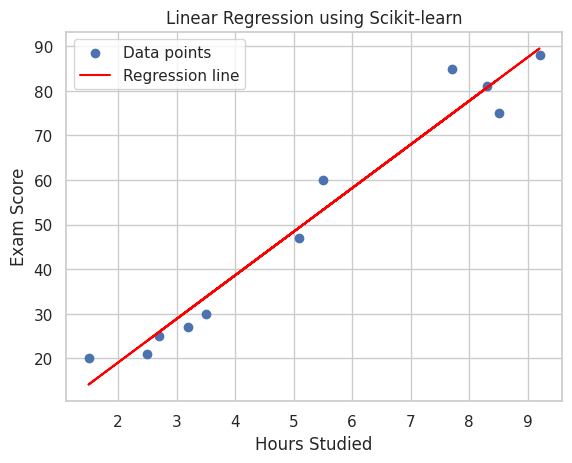

In [23]:
# plot data points and regression line
plt.scatter(X, y, label="Data points")
y_pred_skl = model.predict(X)
plt.plot(X, y_pred_skl, label="Regression line", color='red')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression using Scikit-learn")
plt.legend()
plt.show()

---

## 3. Gradient Descent Implementation  

Without using libraries: 
- Implement linear regression using batch gradient descent  
- Plot cost/error vs iterations  
- Compare learned slope/intercept with scikit-learn’s model.  

In [24]:
# manual implementation of linear regression using gradient descent
# since this is it has single feature, so using univariate linear regression
# initialize parameters
w = 0.0
b = 0.0 
learning_rate = 0.01
n_iterations = 3000 # found this many iterations gives least cost convergence

In [25]:
# convert X and y to numpy arrays for easier calculations
X_values = X.to_numpy().ravel()
y_values = y.to_numpy().ravel()

m = len(X)
costs = []

In [26]:
# start gradient descent 
for i in range(n_iterations):
    y_pred = w * X_values + b
    error = y_pred - y_values

    dw = (1 / m) * np.sum(error * X_values, axis=0)
    db = (1 / m) * np.sum(error, axis=0)
    
    w -= learning_rate * dw
    b -= learning_rate * db

    # using Mean Squared Error (MSE) as cost function
    cost = (1 / (2 * m)) * np.sum(error ** 2, axis=0)
    costs.append(cost)

slope_gd = w
intercept_gd = b
print(f"Learned slope: {slope_gd}")
print(f"Learned intercept: {intercept_gd}")


Learned slope: 9.782427128376929
Learned intercept: -0.4940876304208191


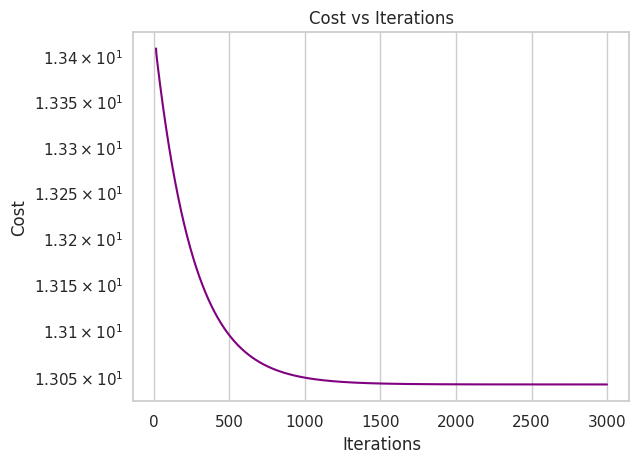

In [27]:
# Plot cost vs iterations
skip = 15  # skip first 15 iterations for better visualization
plt.plot(range(skip, n_iterations), costs[skip:], color="purple") # skip initial high cost values for better visualization
plt.yscale('log') # choosing log scale for better visibility at granular level
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.show()

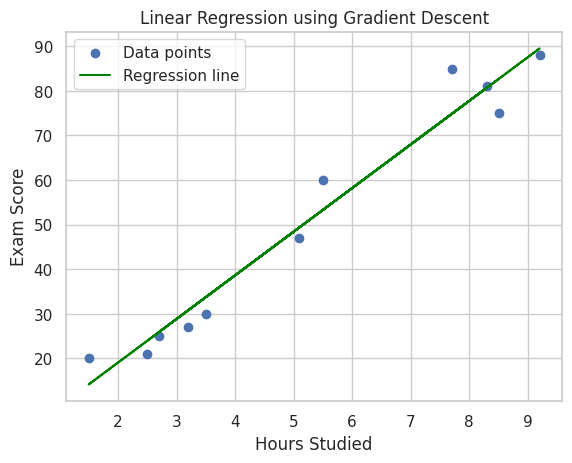

In [28]:
# plot data points and regression line from gradient descent
plt.scatter(X, y, label="Data points")
y_pred_gd = slope_gd * X + intercept_gd
plt.plot(X, y_pred_gd, label="Regression line", color='green')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression using Gradient Descent")
plt.legend()
plt.show()

In [29]:
print(f"Scikit-learn model: Slope = {slope_skl_model}, Intercept = {intercept_skl_model}")
print(f"Gradient Descent model: Slope = {slope_gd}, Intercept = {intercept_gd}")

Scikit-learn model: Slope = 9.783204555657944, Intercept = -0.499172987405764
Gradient Descent model: Slope = 9.782427128376929, Intercept = -0.4940876304208191


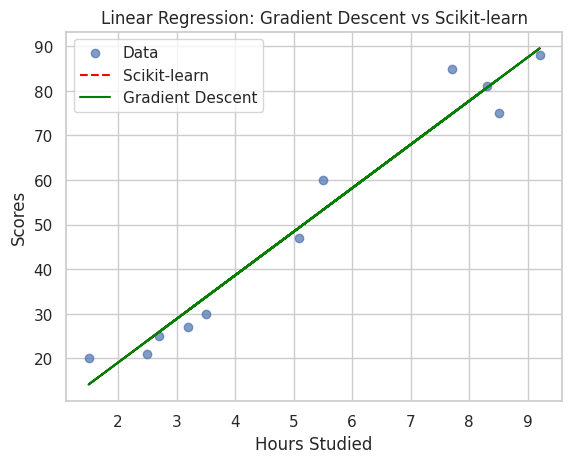

In [30]:
# plot both regression lines for visual comparison
plt.scatter(X_values, y_values, label="Data", alpha=0.7)

plt.plot(
    X_values,
    slope_skl_model * X_values + intercept_skl_model,
    label="Scikit-learn",
    linestyle="--",
    color='red'
)

plt.plot(
    X_values,
    slope_gd * X_values + intercept_gd,
    label="Gradient Descent",
    color='green'
)

plt.xlabel("Hours Studied")
plt.ylabel("Scores")
plt.title("Linear Regression: Gradient Descent vs Scikit-learn")
plt.legend()
plt.show()

Perfect overlap between the two models. 

In [31]:
# quantitative comparison of errors
res_skl = y_values - y_pred_skl
res_gd = y_values - y_pred_gd.to_numpy().ravel()

mse_skl = np.mean(res_skl**2)
mse_gd  = np.mean(res_gd**2)
print("MSE (Scikit-learn):", mse_skl)
print("MSE (Gradient Descent):", mse_gd)
print()

rmse_skl = np.sqrt(mse_skl)
rmse_gd  = np.sqrt(mse_gd)

print("RMSE (Scikit-learn):", rmse_skl)
print("RMSE (Gradient Descent):", rmse_gd)
print()

abs_diff = rmse_gd - rmse_skl
percent_diff = abs_diff / rmse_skl * 100

print(f"Absolute RMSE difference: {abs_diff:.6f}")
print(f"RMSE increase in gradient descent: {percent_diff:.6f}%")

MSE (Scikit-learn): 26.084446578208517
MSE (Gradient Descent): 26.084451820913454

RMSE (Scikit-learn): 5.107293468972438
RMSE (Gradient Descent): 5.107293982229088

Absolute RMSE difference: 0.000001
RMSE increase in gradient descent: 0.000010%


By comparing results from both implementations, I saw almost zero difference when trained gradient descent model with higher number of iterations.